In [18]:
# Okubo-Weiss Parameter
from smode_import import *
f = coriolis_parameter(35)

In [3]:
# Load Dopplerscatt
workdir='/Users/elise/ocean/drifters_chl/'
folder='/Users/elise/data/SMODE-data/DopplerScatt/'
files = sorted(glob(folder+'SMODE_IOP2*.nc'))
files

['/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230406_082606.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230407_125527.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230408_081511.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230410_125752.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230411_124004.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230412_125837.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230413_115421.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230414_121447.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230415_100547.tomoL2CF_v2.nc',
 '/Users/elise/data/SMODE-data/DopplerScatt/SMODE_IOP2_dopplerscatt_20230417_125912.tomoL2C

In [6]:
def compute_divergence(u,v,x,y):

    du_dx = np.ones_like(u)*np.nan
    dv_dy = np.ones_like(v)*np.nan

    du_dx[:,1:-1] = (u[:,2:]-u[:,:-2])/(x[:,2:]-x[:,:-2])
    dv_dy[1:-1,:] = (v[2:,:]-v[:-2,:])/(y[2:,:]-y[:-2,:])

    div = du_dx + dv_dy

    return div

def compute_vorticity(u,v,x,y):
    
    du_dy = np.ones_like(u)*np.nan
    dv_dx = np.ones_like(v)*np.nan
    
    du_dy[1:-1:,:] = (u[2:,:]-u[:-2,:])/(y[2:,:]-y[:-2,:])
    dv_dx[:,1:-1] = (v[:,2:]-v[:,:-2])/(x[:,2:]-x[:,:-2])
    
    vor = dv_dx - du_dy

    return vor

In [9]:
def okubo_weiss(u, v, x, y):
    # W = s_n^2 + s_s^2 - omega^2
    
    # Compute velocity gradients
    du_dx = np.ones_like(u)*np.nan
    dv_dy = np.ones_like(v)*np.nan
    du_dy = np.ones_like(u)*np.nan
    dv_dx = np.ones_like(v)*np.nan
    
    du_dy[1:-1:,:] = (u[2:,:]-u[:-2,:])/(y[2:,:]-y[:-2,:])
    dv_dx[:,1:-1] = (v[:,2:]-v[:,:-2])/(x[:,2:]-x[:,:-2])
    du_dx[:,1:-1] = (u[:,2:]-u[:,:-2])/(x[:,2:]-x[:,:-2])
    dv_dy[1:-1,:] = (v[2:,:]-v[:-2,:])/(y[2:,:]-y[:-2,:])
    
    # Compute Okubo-Weiss components
    sn = du_dx - dv_dy         # normal strain
    ss = dv_dx + du_dy         # shear strain
    zeta = dv_dx - du_dy       # relative vorticity
    
    # Okubo-Weiss parameter
    W = sn**2 + ss**2 - zeta**2

    return W

In [58]:
def compute_kinematics(dopplerscatt):
    # Smooth the input data first
    # We're using a 2D gaussian filter with a standard deviation based 
    # on the full width half max at the desired "resolution"
    delta_in = 200
    delta_out = 2000
    
    sigma_out = delta_out/np.sqrt(2*np.log(2))/2/delta_in
    u_smoothed = scipy.ndimage.gaussian_filter(dopplerscatt.u_current_all_lines.values,sigma_out)
    v_smoothed = scipy.ndimage.gaussian_filter(dopplerscatt.v_current_all_lines.values,sigma_out)
    
    # The DopplerScatt data is already on an x/y UTM grid, so we can easily 
    # compute the derivatives using those coordinates.
    x,y = dopplerscatt.x.values,dopplerscatt.y.values
    x_mesh,y_mesh = np.meshgrid(x,y)
    div = compute_divergence(u_smoothed,v_smoothed,x_mesh,y_mesh)
    vor  = compute_vorticity(u_smoothed,v_smoothed,x_mesh,y_mesh)
    W          = okubo_weiss(u_smoothed,v_smoothed,x_mesh,y_mesh)
    
    # Create dataset
    lon, lat = dopplerscatt.longitude.values, dopplerscatt.latitude.values
    kinematics = xr.Dataset(
        {
        'longitude': xr.DataArray(lon.T, dims=('x','y')),
        'latitude':  xr.DataArray(lat.T, dims=('x','y')),
        'div':       xr.DataArray(div.T, dims=('x','y')),
        'vor':       xr.DataArray(vor.T, dims=('x','y')),
        'W':         xr.DataArray(W.T,   dims=('x','y')),
        },
        coords=
        {
            'x': xr.DataArray(x,dims='x'),
            'y': xr.DataArray(y,dims='y'),
        }
    )
    
    return kinematics
    

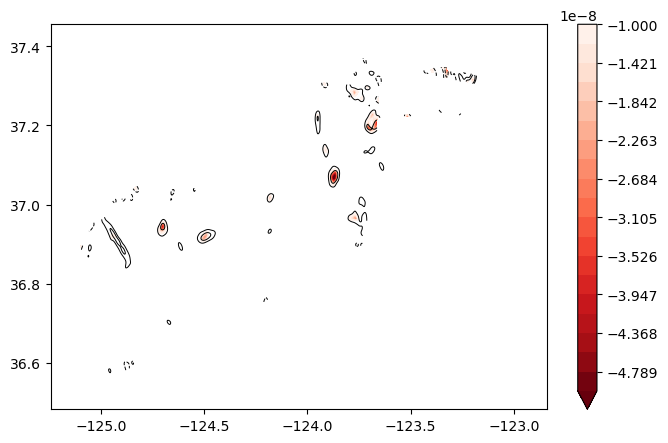

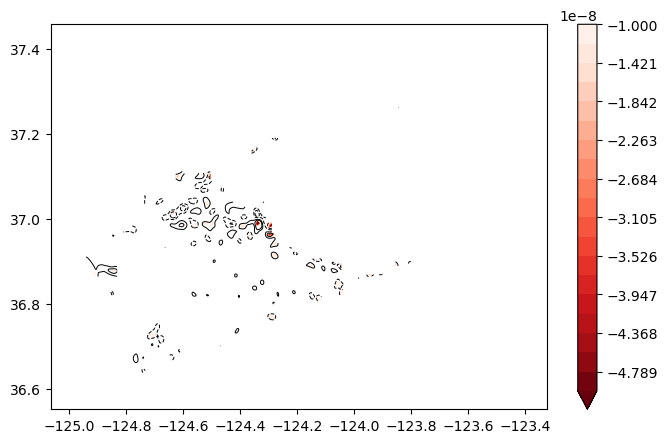

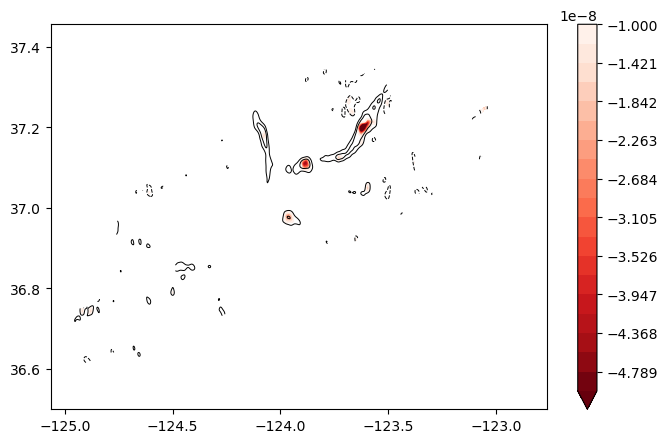

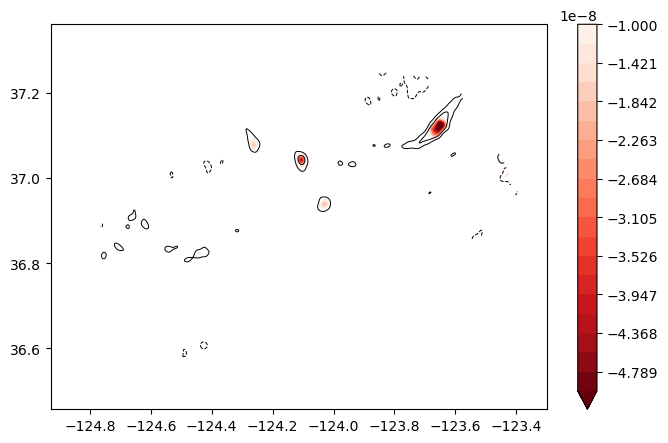

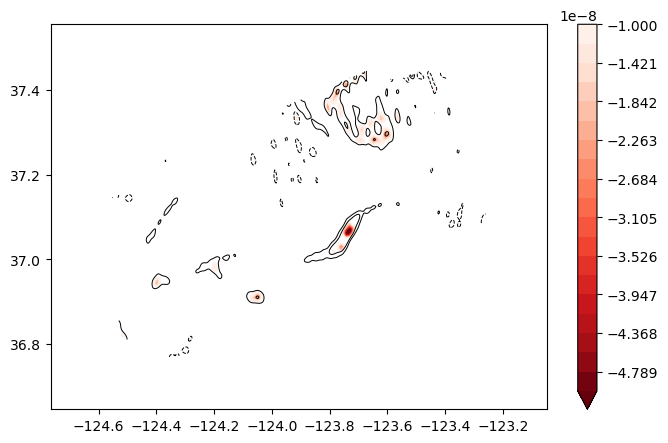

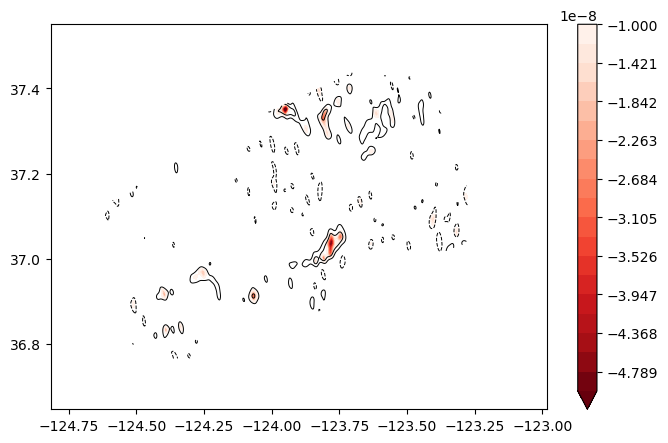

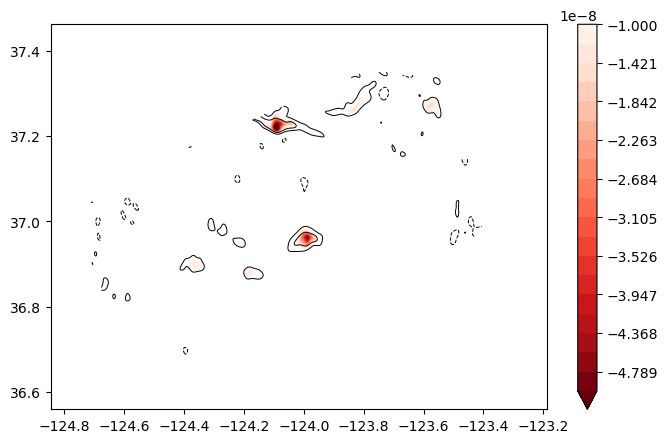

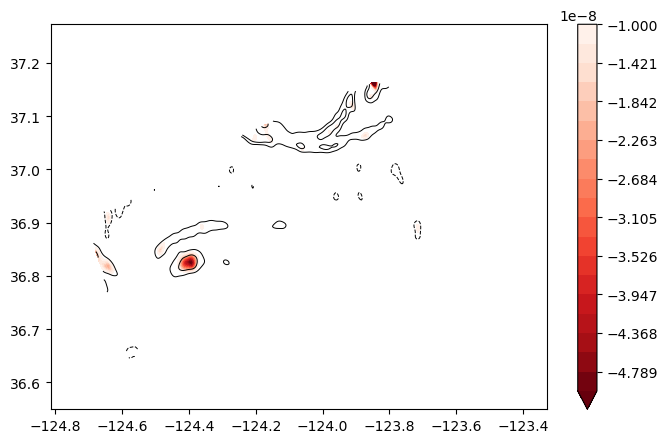

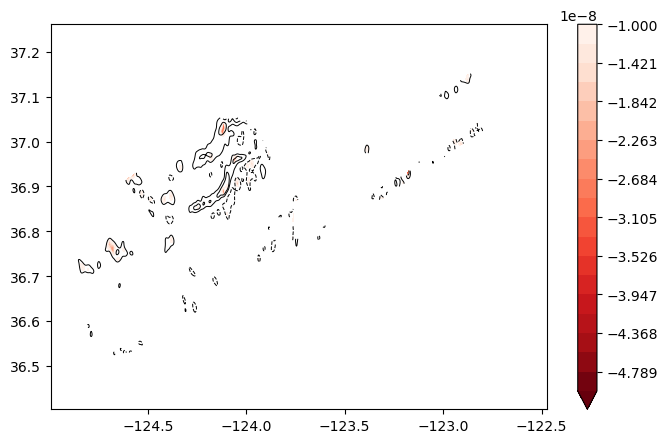

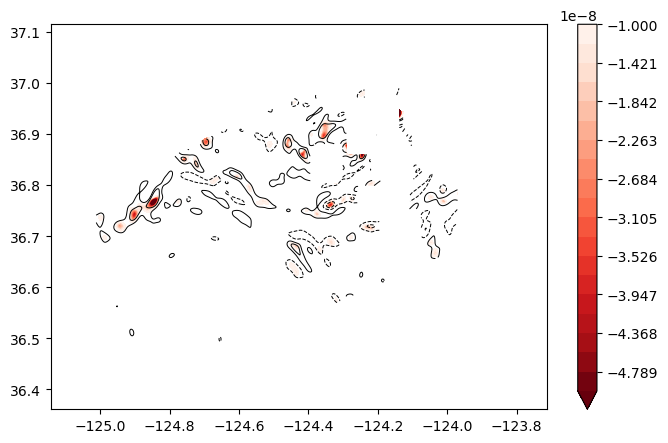

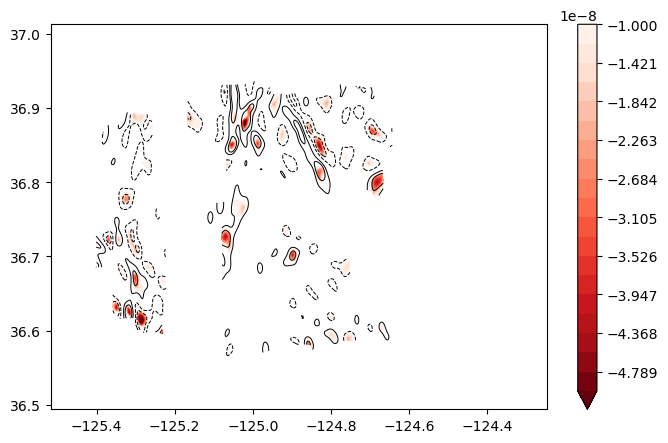

In [93]:
for file in files[9:-1]:
    dopplerscatt = xr.open_dataset(file)
    #time=str(dopplerscatt.mean_line_time.values[0])
    kinematics = compute_kinematics(dopplerscatt)

    # Plot
    plt.figure(figsize=(8,5))
    lon, lat = dopplerscatt.longitude.values, dopplerscatt.latitude.values
    p=plt.contourf(lon, lat, kinematics.W.T, np.linspace(-5e-8,-1e-8,20), cmap='Reds_r', extend='min')
    cbar=plt.colorbar()
    plt.contour(lon, lat, (kinematics.vor/f).T,levels=[-2,-1,1,2],colors='k',linewidths=0.7)
    plt.show();
    

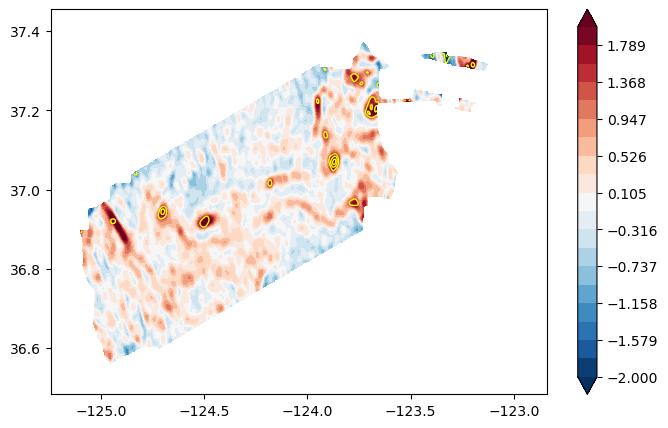

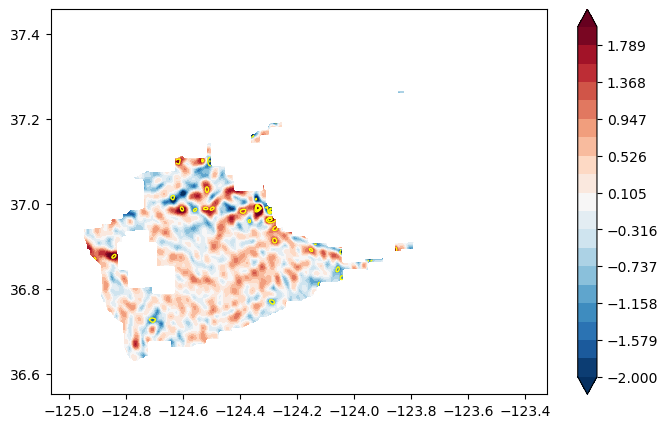

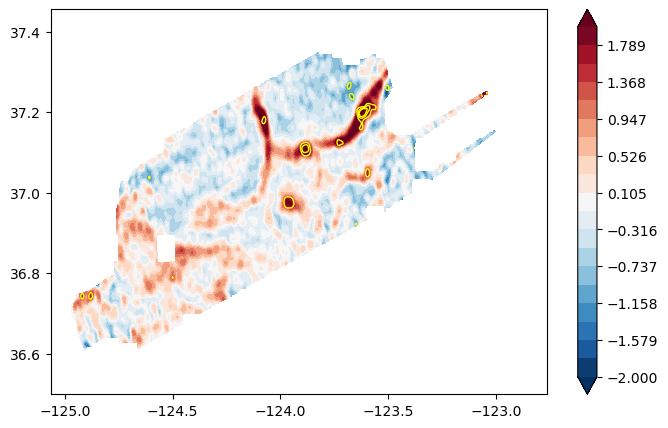

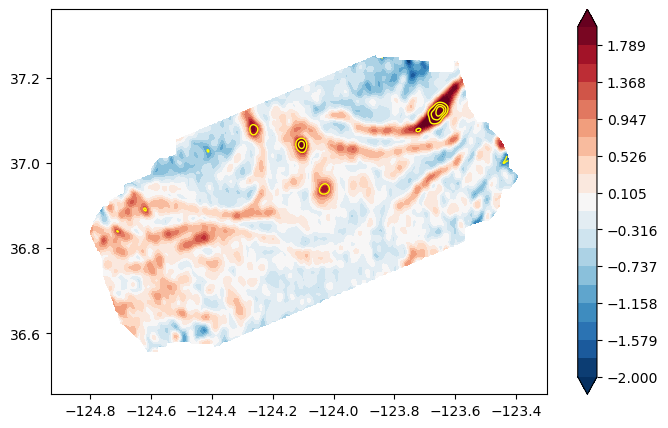

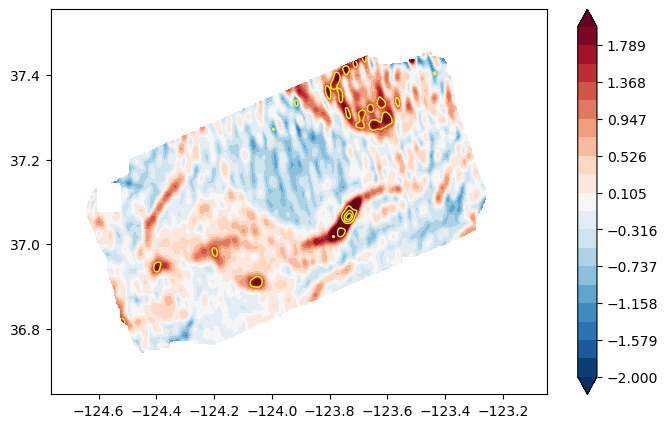

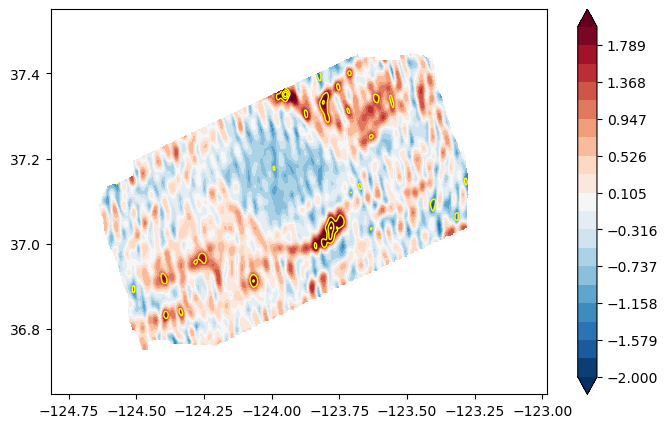

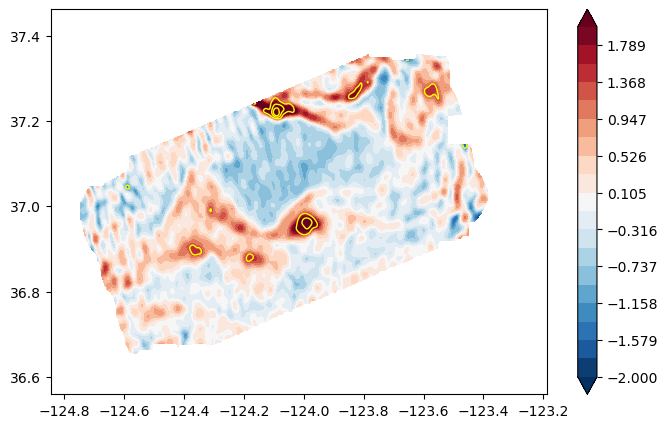

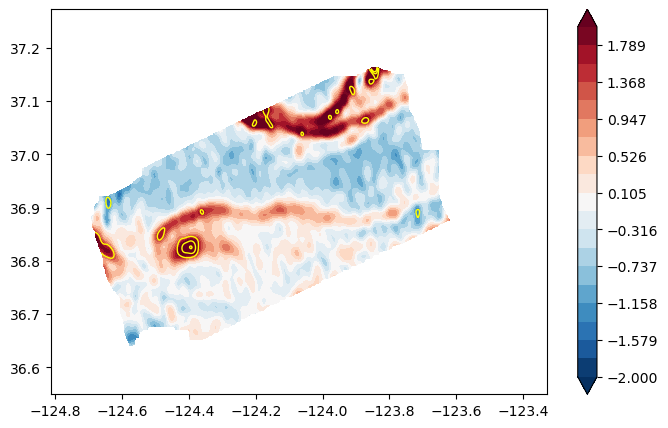

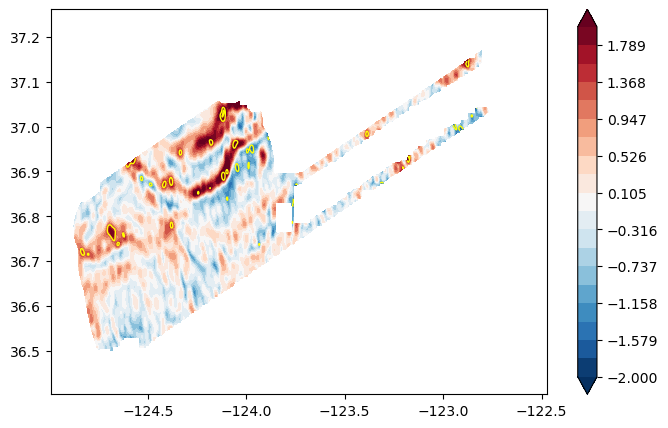

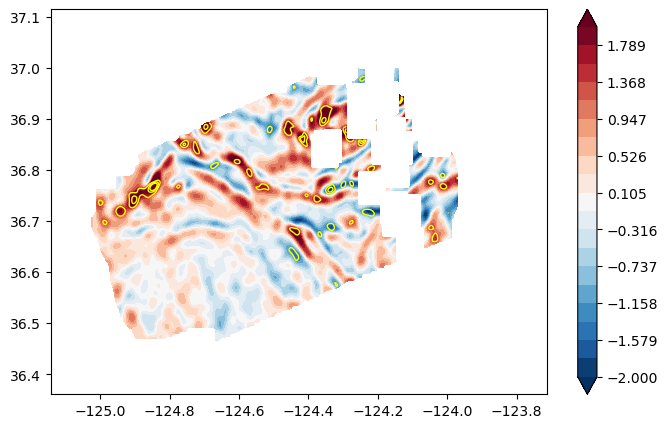

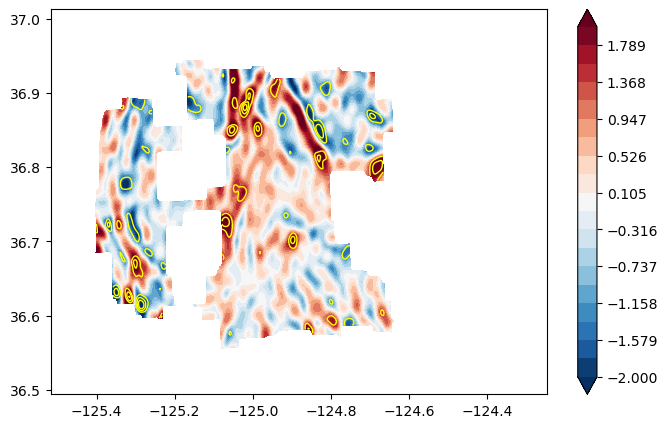

In [115]:
for file in files[9:-1]:
    dopplerscatt = xr.open_dataset(file)
    #time=str(dopplerscatt.mean_line_time.values[0])
    kinematics = compute_kinematics(dopplerscatt)

    # Plot
    plt.figure(figsize=(8,5))
    lon, lat = dopplerscatt.longitude.values, dopplerscatt.latitude.values
    p=plt.contourf(lon, lat, (kinematics.vor/f).T,levels=np.linspace(-2,2,20),cmap='RdBu_r', extend='both')
    cbar=plt.colorbar()
    plt.contour(lon, lat, kinematics.W.T*-1, levels=np.arange(1,6,2)*1e-8, colors='yellow', linewidths=1)
    plt.show();

In [86]:
xr.open_dataset('dopplerscatt_gridded.nc')

<xarray.Dataset> Size: 672MB
Dimensions:     (lat: 1000, lon: 1000, time: 21)
Coordinates:
  * lat         (lat) float64 8kB 36.0 36.0 36.0 36.01 ... 37.99 38.0 38.0 38.0
  * lon         (lon) float64 8kB -126.0 -126.0 -126.0 ... -122.0 -122.0 -122.0
  * time        (time) <U29 2kB '2023-04-06T15:47:19.000000000' ... '2023-04-...
Data variables:
    u           (time, lat, lon) float64 168MB ...
    v           (time, lat, lon) float64 168MB ...
    divergence  (time, lat, lon) float64 168MB ...
    vorticity   (time, lat, lon) float64 168MB ...